# 数据处理和转换

## torch.tensor 创建一个张量

In [1]:
import torch

x = torch.tensor([1,2,3])
print(x)

tensor([1, 2, 3])


## torch.zeros torch.ones 创建全0或全1的张量


In [2]:
zeros = torch.zeros(3)
ones = torch.ones(4)

print(zeros)
print(ones)

tensor([0., 0., 0.])
tensor([1., 1., 1., 1.])


## 创建正太分布的随机张量

In [3]:
randn = torch.randn(3,3)
print(randn)

tensor([[-1.2172,  0.2874, -0.0818],
        [-0.4236,  0.6031,  2.4974],
        [ 1.1170, -0.7589, -1.1794]])


## torch.from_numpy 将numpy数组装换为张量

In [4]:
import numpy as np
np_array = np.array([1,2,3])
print(np_array)
tensor = torch.from_numpy(np_array)
print(tensor)

[1 2 3]
tensor([1, 2, 3])


## torch.mean torch.std 计算张量的均值和标准差

In [5]:
mean = torch.mean(tensor.float())
std = torch.std(tensor.float())
print(mean)
print(std)

tensor(2.)
tensor(1.)


## torch.var 计算张量的方差

In [6]:
var = torch.var(tensor.float())
print(var)

tensor(1.)


# 构建神经网络

## torch.nn.Linear 全连接层

In [13]:
linear  = torch.nn.Linear(10,5)
print(linear)

Linear(in_features=10, out_features=5, bias=True)


## torch.nn.Conv2d 2D卷积层

In [8]:
conv2d = torch.nn.Conv2d(in_channels=1,out_channels=3,kernel_size=3)
print(conv2d)

Conv2d(1, 3, kernel_size=(3, 3), stride=(1, 1))


## torch.nn.ReLU  ReLU激活函数

In [10]:
relu = torch.nn.ReLU()
print(relu)

ReLU()


## torch.nn.Sigmoid Sigmoid激活函数

In [11]:
sigmoid = torch.nn.Sigmoid()
print(sigmoid)

Sigmoid()


# 训练与优化

## torch.optim.Adam torch.optim.SGD常见的优化器



In [ ]:
torch.optim (模块)
├── SGD (类)
├── Adam (类)
├── AdamW (类)
├── RMSprop (类)
├── Adagrad (类)
├── Adadelta (类)
├── Adamax (类)
├── LBFGS (类)
├── Rprop (类)
├── ASGD (类)
├── SparseAdam (类)
└── lr_scheduler (子模块)
    ├── StepLR
    ├── MultiStepLR
    ├── ExponentialLR
    ├── CosineAnnealingLR
    └── ...

In [16]:
adam = torch.optim.Adam(linear.parameters(),lr=0.001)
sgd = torch.optim.SGD(linear.parameters(),lr=0.001)
adamw = torch.optim.AdamW(linear.parameters(), lr=0.001)
rmsprop = torch.optim.RMSprop(linear.parameters(), lr=0.001)

print(adam)
print(sgd)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    lr: 0.001
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)


# 数据加载和处理

## torch.utils.data.Dataset 自定义数据集类

In [17]:
# 定义自定义数据集
class CustomDataset(torch.utils.data.Dataset):
    def __init__(self):
        pass
    def __len__(self):
        pass

## torch.utils.data.DataLoader 批量加载数据集的工具

In [ ]:
dataset = CustomDataset()
dataloader = torch.utils.data.DataLoader(dataset,batch_size=32,shuffle=True)

# 模型保存与加载

## torch.save torch.load 保存与加载模型或张量

In [ ]:
torch.save(model.state_dict(),'model.path')

# 加载模型
model = TheModelClass(*args,**kwargs)
model.load_state_dict(torch.load('model.path'))

# 函数式接口

torch.nn.functional 提供了一些列函数式的API
- 例如torch.nn.functional.relu()用于Relu激活

# 高级数据处理和转换

torch.index_select() 按指定维度和索引选择数据

In [20]:
import  torch
x = torch.tensor(
    [
        [1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]
    ]
)

indices = torch.tensor([0,2])
result = torch.index_select(x,dim=0,index=indices)
result_1 = torch.index_select(x,dim=1,index=indices)
print(result)
print(result_1)

tensor([[1, 2, 3],
        [7, 8, 9]])
tensor([[1, 3],
        [4, 6],
        [7, 9]])


In [21]:
# 3D 张量: (batch, seq_len, hidden)
x = torch.randn(2, 4, 5)  # batch=2, seq=4, hidden=5
print(x)

# 选择特定的序列位置
positions = torch.tensor([0, 2, 3])  # 选择第0, 2, 3个位置
selected = torch.index_select(x, dim=1, index=positions)
print(selected.shape)  # (2, 3, 5) - seq_len 从 4 变成 3

# 选择特定的 batch
batches = torch.tensor([1])  # 只选第1个batch
selected = torch.index_select(x, dim=0, index=batches)
print(selected.shape)  # (1, 4, 5)

tensor([[[-2.0418, -1.1336, -1.2689,  1.1597, -2.0334],
         [-0.3054, -0.8928,  0.2582, -0.7106, -0.9195],
         [-1.5974,  1.3020, -1.8919,  0.9963,  0.5710],
         [-1.1927, -0.6887,  1.0557, -0.5099, -1.7921]],

        [[ 2.3595,  1.3277,  1.4195,  0.9418,  1.0570],
         [-0.9424,  0.8277,  0.0277, -0.9847, -1.4663],
         [-1.3771, -0.1614, -0.2867,  1.5409,  1.3908],
         [-0.2157, -1.3446,  0.0112, -0.2783, -1.0943]]])
torch.Size([2, 3, 5])
torch.Size([1, 4, 5])


In [22]:
x = torch.randn(3, 4)

# 方法1: index_select - 结果保持维度，可以重复选择
indices = torch.tensor([0, 0, 1, 1, 2])  # 可以重复
result = torch.index_select(x, 0, indices)  # shape: (5, 4)

# 方法2: [] 索引 - 更灵活但行为不同
result = x[[0, 0, 1, 1, 2]]  # 效果相同，但 index_select 更快

# 关键区别: index_select 要求 index 是 1D LongTensor
# [] 索引支持广播、布尔掩码等

## torch.masked_select(） 根据布尔掩码选择元素

In [23]:
import torch

x = torch.tensor([1, 2, 3, 4, 5])
mask = torch.tensor([True, False, True, False, True])

result = torch.masked_select(x, mask)
print(result)  # tensor([1, 3, 5])
print(result.shape)  # torch.Size([3]) - 1D

tensor([1, 3, 5])
torch.Size([3])


In [24]:
x = torch.tensor([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])

mask = x > 5  # 布尔条件
print(mask)
# tensor([[False, False, False],
#         [False, False,  True],
#         [ True,  True,  True]])

result = torch.masked_select(x, mask)
print(result)  # tensor([6, 7, 8, 9]) - 按行优先展平
print(result.shape)  # torch.Size([4])

tensor([[False, False, False],
        [False, False,  True],
        [ True,  True,  True]])
tensor([6, 7, 8, 9])
torch.Size([4])


In [25]:
x = torch.tensor([[1, 2, 3], [4, 5, 6]])

# 方法1: masked_select - 返回 1D
mask = x > 3
result = torch.masked_select(x, mask)  # tensor([4, 5, 6])

# 方法2: [] 布尔索引 - 返回 1D（效果相同）
result = x[x > 3]  # tensor([4, 5, 6])

# 关键区别：masked_select 可以处理广播，[] 索引更直观

In [27]:
# 序列有 padding，需要只计算有效位置
logits = torch.randn(2, 5)  # (batch, seq_len)
attention_mask = torch.tensor([
    [1, 1, 1, 0, 0],  # 有效长度3
    [1, 1, 1, 1, 0]   # 有效长度4
]).bool()
print(attention_mask)

# 只选择有效位置的 logits
valid_logits = torch.masked_select(logits, attention_mask)
# shape: (7,) = 3 + 4

# 对比：使用 [] 索引（更常用）
valid_logits = logits[attention_mask]  # 相同结果，更简洁

tensor([[ True,  True,  True, False, False],
        [ True,  True,  True,  True, False]])


## torch.add torch.mul torch.div 张量的加 乘 除运行

In [30]:
mask = torch.tensor([[1, 0, 1], [0, 1, 0], [1, 0, 1]])  # float 类型

print(mask)
mask = (x >0).bool()
print(mask)

tensor([[1, 0, 1],
        [0, 1, 0],
        [1, 0, 1]])
tensor([[True, True, True],
        [True, True, True]])


In [34]:
# 矩阵 + 向量（广播）
x = torch.randn(3, 4)      # (3, 4)
print(x)
bias = torch.randn(4)       # (4,) → 广播为 (3, 4)
print(bias)

result = torch.add(x, bias)  # 每行加上相同的 bias
# 等价于: x + bias
print(result)

tensor([[-0.7730, -0.8647, -0.9815, -0.0852],
        [ 2.3772, -1.1347, -0.5232, -1.0971],
        [-0.1259,  0.7693,  1.0984, -1.1478]])
tensor([ 0.4341,  0.4627,  0.7098, -1.3768])
tensor([[-0.3389, -0.4020, -0.2717, -1.4620],
        [ 2.8113, -0.6720,  0.1866, -2.4739],
        [ 0.3081,  1.2320,  1.8082, -2.5246]])


# 模型分析与调试

## torch.autograd.gradcheck 用于检查梯度的正确性

用途：验证解析梯度 vs 数值梯度的一致性

In [ ]:
torch.autograd.gradcheck(
    func,               # 要检查的函数
    inputs,             # 输入张量（元组）
    eps=1e-06,          # 有限差分的步长
    atol=1e-05,         # 绝对容差
    rtol=1e-03,         # 相对容差
    gen_non_contig_grad_outputs=False,
    raise_exception=True,
    nondet_tol=0.0,
    check_undefined_grad=True,
    check_grad_dtypes=False,
    check_batched_grad=False,
    check_forward_ad=False,
    check_backward_ad=True,
    fast_mode=False,
    masked=None
) → bool

In [35]:
import torch
from torch.autograd import gradcheck

# 定义可微函数
def my_square(x):
    return x ** 2

# 准备输入（需要 requires_grad=True）
x = torch.randn(3, 3, dtype=torch.float64, requires_grad=True)

# 验证梯度
test_passed = gradcheck(my_square, (x,))
print(f"Gradient check passed: {test_passed}")  # True

Gradient check passed: True


In [ ]:
import torch
import torch.nn as nn
from torch.autograd import gradcheck

class MyLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(out_features, in_features))
        self.bias = nn.Parameter(torch.randn(out_features))
    
    def forward(self, x):
        return torch.matmul(x, self.weight.t()) + self.bias

# 实例化并测试
layer = MyLinear(5, 3).double()  # 必须用 float64 保证精度
x = torch.randn(2, 5, dtype=torch.float64, requires_grad=True)

# 验证前向和反向
test_passed = gradcheck(layer, (x,))
print(f"Custom layer gradient check: {test_passed}")

In [36]:
from torch.autograd import gradcheck

def custom_grpo_loss(logits, labels, advantages):
    """
    自定义 GRPO 损失，需要验证梯度正确性
    """
    log_probs = torch.log_softmax(logits, dim=-1)
    selected_log_probs = torch.gather(log_probs, -1, labels.unsqueeze(-1)).squeeze(-1)
    loss = -(selected_log_probs * advantages).mean()
    return loss

# 测试数据（必须用 float64）
batch_size = 4
seq_len = 10
vocab_size = 100

logits = torch.randn(batch_size, seq_len, vocab_size, 
                     dtype=torch.float64, requires_grad=True)
labels = torch.randint(0, vocab_size, (batch_size, seq_len))
advantages = torch.randn(batch_size, seq_len, dtype=torch.float64)

# 验证梯度
test_passed = gradcheck(
    custom_grpo_loss, 
    (logits, labels, advantages),
    eps=1e-4,
    atol=1e-3,
    rtol=1e-2
)
print(f"GRPO loss gradient check: {test_passed}")

GRPO loss gradient check: True


In [ ]:
def kl_divergence(p_logits, q_logits):
    """
    KL(p||q) = Σ p * log(p/q)
    """
    p = torch.softmax(p_logits, dim=-1)
    log_p = torch.log_softmax(p_logits, dim=-1)
    log_q = torch.log_softmax(q_logits, dim=-1)
    
    kl = (p * (log_p - log_q)).sum(dim=-1)
    return kl.mean()

# 验证
p = torch.randn(10, 5, dtype=torch.float64, requires_grad=True)
q = torch.randn(10, 5, dtype=torch.float64, requires_grad=True)

test_passed = gradcheck(kl_divergence, (p, q))
print(f"KL divergence gradient check: {test_passed}")

In [ ]:
def compute_gae_advantages(rewards, values, gamma=0.99, lambda_=0.95):
    """
    广义优势估计（GAE），需要验证梯度流
    """
    advantages = []
    gae = 0
    
    for t in reversed(range(len(rewards))):
        if t == len(rewards) - 1:
            next_value = 0
        else:
            next_value = values[t + 1]
        
        delta = rewards[t] + gamma * next_value - values[t]
        gae = delta + gamma * lambda_ * gae
        advantages.insert(0, gae)
    
    return torch.stack(advantages)

# 验证（需要包装成函数）
def gae_wrapper(rewards, values):
    return compute_gae_advantages(rewards, values).sum()

rewards = torch.randn(5, dtype=torch.float64, requires_grad=True)
values = torch.randn(5, dtype=torch.float64, requires_grad=True)

test_passed = gradcheck(gae_wrapper, (rewards, values))
print(f"GAE gradient check: {test_passed}")

### 当模型不收敛或梯度异常时的调试流程

In [ ]:
def debug_gradient_issue():
    """
    当模型不收敛或梯度异常时的调试流程
    """
    # 1. 隔离问题：最小化测试用例
    minimal_input = torch.randn(2, 3, dtype=torch.float64, requires_grad=True)
    
    # 2. 检查前向传播
    try:
        output = my_complex_function(minimal_input)
        print("Forward pass OK")
    except Exception as e:
        print(f"Forward pass failed: {e}")
        return
    
    # 3. 检查反向传播
    try:
        loss = output.sum()
        loss.backward()
        print("Backward pass OK")
    except Exception as e:
        print(f"Backward pass failed: {e}")
        return
    
    # 4. 数值验证梯度
    try:
        test_passed = gradcheck(my_complex_function, (minimal_input,))
        print(f"Gradient check: {test_passed}")
    except Exception as e:
        print(f"Gradient check failed: {e}")
        
        # 5. 详细分析
        # 使用 torch.autograd.anomaly_mode 检测异常
        with torch.autograd.anomaly_mode():
            output = my_complex_function(minimal_input)
            output.sum().backward()

## torch.autograd.profiler.profile性能分析工具，用于分析模型的时间和内存消耗

用于记录和分析模型运行时的性能数据，包括：
- 每个算子的执行时间
- CUDA 内核执行时间
- 内存使用情况
- CPU/GPU 时间 breakdown

In [ ]:
torch.autograd.profiler.profile(
    enabled=True,           # 是否启用分析
    use_cuda=False,         # 是否分析 CUDA
    record_shapes=False,    # 是否记录张量形状
    with_flops=False,       # 是否估算 FLOPs
    profile_memory=False,   # 是否分析内存
    with_stack=False,       # 是否记录 Python 调用栈
    with_modules=False,     # 是否记录模块层次结构
    use_kineto=False,       # 是否使用 Kineto 后端（推荐 True）
    use_cpu=True,           # 是否分析 CPU
)

### 基本性能分析


In [ ]:
import torch
from torch.autograd import profiler

# 创建模型和数据
model = torch.nn.TransformerEncoderLayer(d_model=512, nhead=8, batch_first=True)
x = torch.randn(32, 100, 512)  # (batch, seq, hidden)

# 使用 profiler
with profiler.profile(
    activities=[
        profiler.ProfilerActivity.CPU,
        profiler.ProfilerActivity.CUDA,  # 如果有 GPU
    ],
    record_shapes=True,
    with_flops=True,
    profile_memory=True,
) as prof:
    
    # 前向传播
    output = model(x)
    
    # 反向传播
    loss = output.sum()
    loss.backward()

# 打印结果（按时间排序）
print(prof.key_averages().table(sort_by="cuda_time_total" if torch.cuda.is_available() else "cpu_time_total"))

In [ ]:
-------------------------  ---------------  ---------------  ---------------  ---------------  ---------------  ---------------  ---------------  ---------------  ---------------  
Name                       Self CPU total %  Self CPU total   CPU total %      CPU total        CPU time avg     CUDA total %     CUDA total       CUDA time avg    # of Calls       
-------------------------  ---------------  ---------------  ---------------  ---------------  ---------------  ---------------  ---------------  ---------------  ---------------  
aten::addmm                15.2%            2.345ms          18.5%            2.856ms          45.250us         20.1%            3.456ms          54.720us         64               
aten::transpose            8.5%             1.312ms          9.2%             1.420ms          2.215us          5.3%             911.234us        1.421us          640              
aten::matmul               12.3%            1.898ms          22.1%            3.412ms          53.312us         25.6%            4.401ms          68.766us         64               
...

### 在 GRPO/RL 中的实际应用
- 场景 1：分析 GRPO 训练瓶颈

In [ ]:
from torch.autograd import profiler

def profile_grpo_training_step(trainer, batch):
    """
    分析 GRPO 训练步骤的性能瓶颈
    """
    with profiler.profile(
        activities=[
            profiler.ProfilerActivity.CPU,
            profiler.ProfilerActivity.CUDA,
        ],
        record_shapes=True,
        with_flops=True,
        profile_memory=True,
        with_stack=True,  # 记录调用栈，便于定位
    ) as prof:
        
        # 1. 生成阶段
        with profiler.record_function("generation"):
            completions = trainer.generate(batch)
        
        # 2. 奖励计算
        with profiler.record_function("reward_computation"):
            rewards = trainer.compute_rewards(batch, completions)
        
        # 3. 优势计算
        with profiler.record_function("advantage_computation"):
            advantages = trainer.compute_advantages(rewards)
        
        # 4. 损失计算
        with profiler.record_function("loss_computation"):
            loss = trainer.compute_loss(completions, advantages)
        
        # 5. 反向传播
        with profiler.record_function("backward"):
            loss.backward()
        
        # 6. 优化器步骤
        with profiler.record_function("optimizer_step"):
            trainer.optimizer.step()
            trainer.optimizer.zero_grad()

    # 打印详细报告
    print(prof.key_averages(group_by_input_shape=True).table(
        sort_by="cuda_time_total", 
        row_limit=20
    ))
    
    # 导出 Chrome trace 文件（可视化分析）
    prof.export_chrome_trace("grpo_profile.json")
    
    return prof

# 使用
profile_grpo_training_step(trainer, batch)

- 场景 2：分析内存瓶颈（OOM 调试）

In [ ]:
from torch.autograd import profiler

def profile_memory_usage(model, batch_size=32, seq_len=512):
    """
    分析 GRPO 训练中的内存使用情况，定位 OOM 原因
    """
    with profiler.profile(
        activities=[profiler.ProfilerActivity.CPU, profiler.ProfilerActivity.CUDA],
        profile_memory=True,      # 关键：启用内存分析
        record_shapes=True,
    ) as prof:
        
        # 模拟 GRPO 前向传播（生成多个样本）
        x = torch.randn(batch_size, seq_len, 512, device='cuda')
        
        with profiler.record_function("forward"):
            output = model(x)
        
        with profiler.record_function("backward"):
            loss = output.sum()
            loss.backward()

    # 打印内存使用
    print(prof.key_averages().table(sort_by="cuda_memory_usage", row_limit=10))
    
    # 查找内存峰值
    for event in prof.key_averages():
        if event.cuda_memory_usage > 1e9:  # > 1GB
            print(f"High memory usage: {event.key}: {event.cuda_memory_usage / 1e9:.2f} GB")

# 使用
profile_memory_usage(model)

- 场景 3：分析分布式训练

In [ ]:
import torch.distributed as dist
from torch.autograd import profiler

def profile_distributed_grpo(rank, world_size):
    """
    分析分布式 GRPO 训练中的通信瓶颈
    """
    setup_distributed(rank, world_size)
    
    model = create_grpo_model().cuda(rank)
    ddp_model = torch.nn.parallel.DistributedDataParallel(model, device_ids=[rank])
    
    with profiler.profile(
        activities=[
            profiler.ProfilerActivity.CPU,
            profiler.ProfilerActivity.CUDA,
        ],
        with_flops=True,
    ) as prof:
        
        for step in range(10):
            batch = get_batch(rank)
            
            with profiler.record_function(f"step_{step}_forward"):
                output = ddp_model(batch)
            
            with profiler.record_function(f"step_{step}_backward"):
                loss = output.sum()
                loss.backward()
            
            # 特别注意 all_reduce 操作（分布式通信）
            with profiler.record_function(f"step_{step}_all_reduce"):
                ddp_model.gradient_sync()  # 梯度同步

    if rank == 0:
        print(prof.key_averages().table(sort_by="cuda_time_total"))
        prof.export_chrome_trace(f"distributed_grpo_rank{rank}.json")

### torcviz： 一个非官方的可视化工具，用于绘制模型的计算图

torchviz 主要用于开发和调试阶段，生产环境不需要。它生成的计算图可以帮助你快速定位梯度问题，特别是在实现复杂的 RL 算法如 GRPO 时。

In [ ]:
 关键用途：                              │
│  1. 理解模型计算流程                      │
│  2. 调试梯度断点/泄漏                     │
│  3. 可视化复杂损失函数（如 GRPO）         │
│  4. 教学演示                             │
│                                         │
│  在 GRPO 中：                            │
│  - 验证 policy_loss 和 kl_loss 的梯度流  │
│  - 检查 advantages 是否正确广播          │
│  - 确认所有参数都参与梯度更新      

In [2]:
!pip install torchviz

zsh:1: command not found: pip


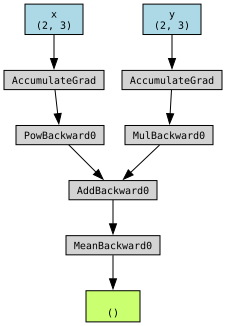

In [3]:
import torch
from torchviz import make_dot

# 创建计算
x = torch.randn(2, 3, requires_grad=True)
y = torch.randn(2, 3, requires_grad=True)
z = x ** 2 + 3 * y
loss = z.mean()

# 可视化
dot = make_dot(loss, params={'x': x, 'y': y})
dot.render('simple_graph', format='png', cleanup=True)  # 保存为 PNG
# 或直接在 Jupyter 显示
dot


In [ ]:
import torch
import torch.nn as nn
from torchviz import make_dot

class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(10, 5)
        self.fc2 = nn.Linear(5, 1)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

model = SimpleNet()
x = torch.randn(4, 10)
y = model(x)
loss = y.sum()

# 可视化
dot = make_dot(loss, params=dict(model.named_parameters()))
dot.render('network_graph', format='png')
dot

# 高级网络构建

## torch.nn.LSTM 长短期记忆网络层

In [ ]:
import torch
import torch.nn as nn

# 定义 LSTM
lstm = nn.LSTM(
    input_size=10,    # 输入特征维度
    hidden_size=20,   # 隐藏状态维度
    num_layers=1,     # 单层
    batch_first=True  # 输入格式: (batch, seq, feature)
)

# 输入数据
batch_size = 4
seq_len = 5
input_dim = 10

x = torch.randn(batch_size, seq_len, input_dim)  # (4, 5, 10)

# 前向传播
output, (hidden, cell) = lstm(x)

print(f"output shape: {output.shape}")   # (4, 5, 20) - 所有时间步的隐藏状态
print(f"hidden shape: {hidden.shape}")   # (1, 4, 20) - 最后时间步的隐藏状态
print(f"cell shape: {cell.shape}")       # (1, 4, 20) - 最后时间步的细胞状态

In [ ]:
# 多层双向 LSTM
lstm = nn.LSTM(
    input_size=10,
    hidden_size=20,
    num_layers=2,           # 2 层
    batch_first=True,
    dropout=0.3,            # 层间 dropout
    bidirectional=True      # 双向
)

x = torch.randn(4, 5, 10)  # (batch, seq, input_dim)

output, (hidden, cell) = lstm(x)

print(f"output shape: {output.shape}")   
# (4, 5, 40) - 双向，所以 hidden_size * 2 = 40

print(f"hidden shape: {hidden.shape}")   
# (4, 4, 20) - (num_layers * num_directions, batch, hidden_size)
# 4 = 2 层 * 2 方向

# 分离双向的隐藏状态
# hidden[0] = 第1层正向最后状态
# hidden[1] = 第1层反向最后状态  
# hidden[2] = 第2层正向最后状态
# hidden[3] = 第2层反向最后状态

## torch.nn.GRU 门控循环单元层

## torch.autograd.Function: 用于创建自定义的可微分操作

torch.autograd.Function 允许你自定义自动求导（autograd）行为，实现：
- 自定义前向传播
- 自定义反向传播（梯度计算）
- 优化性能（融合操作）
- 实现特殊算子



In [ ]:

┌─────────────────────────────────────────┐
│  torch.autograd.Function                │
│                                         │
│  用途：自定义自动求导行为                  │
│  核心：forward() + backward()            │
│  场景：                                  │
│   - 优化内存使用（checkpoint）            │
│   - 融合多个操作（性能优化）              │
│   - 实现特殊梯度（如梯度裁剪、停止梯度）   │
│   - 对接自定义 CUDA kernel               │
│                                         │
│  注意：确保 backward 正确性，建议用       │
│        gradcheck 验证                    │
└─────────────────────────────────────────┘

In [ ]:
class CustomFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, *inputs):
        """
        前向传播
        ctx: 上下文对象，用于保存反向传播所需信息
        inputs: 输入张量
        """
        # 1. 保存需要的信息
        ctx.save_for_backward(tensor1, tensor2, ...)
        ctx.some_attr = value  # 保存非张量属性
        
        # 2. 计算输出
        output = some_computation(inputs)
        
        return output
    
    @staticmethod
    def backward(ctx, grad_output):
        """
        反向传播
        grad_output: 上游传来的梯度 (dL/dy)
        
        返回: 对每个输入的梯度 (dL/dx1, dL/dx2, ...)
        """
        # 1. 恢复保存的张量
        tensor1, tensor2 = ctx.saved_tensors
        
        # 2. 计算梯度
        grad_input1 = ...  # dL/dx1 = dL/dy * dy/dx1
        grad_input2 = ...  # dL/dx2
        
        return grad_input1, grad_input2, ...

In [ ]:
class GRPOLossFunction(torch.autograd.Function):
    """
    自定义 GRPO 损失函数，融合前向和反向传播以节省内存
    """
    @staticmethod
    def forward(ctx, policy_log_probs, ref_log_probs, old_log_probs, advantages, beta):
        """
        输入：
            policy_log_probs: [B, G, seq_len]  当前策略 log prob
            ref_log_probs:    [B, G, seq_len]  参考模型 log prob
            old_log_probs:    [B, G, seq_len]  旧策略 log prob
            advantages:       [B, G]           优势值
            beta:             scalar           KL 系数
        """
        # 保存必要信息（不保存所有中间张量以节省内存）
        ctx.save_for_backward(policy_log_probs, ref_log_probs, old_log_probs, advantages)
        ctx.beta = beta
        
        # 计算比率
        log_ratio = policy_log_probs - old_log_probs
        ratio = torch.exp(log_ratio)
        
        # PPO 裁剪
        clipped_ratio = torch.clamp(ratio, 0.8, 1.2)  # epsilon=0.2
        
        # 扩展优势
        adv_expanded = advantages.unsqueeze(-1)
        
        # 策略损失
        surr1 = ratio * adv_expanded
        surr2 = clipped_ratio * adv_expanded
        policy_loss = -torch.min(surr1, surr2)
        
        # KL 散度
        log_ratio_ref = ref_log_probs - policy_log_probs
        kl = torch.exp(log_ratio_ref) - log_ratio_ref - 1
        
        # 总损失（平均）
        loss = (policy_loss + beta * kl).mean()
        
        # 保存用于反向传播的中间结果
        ctx.mark_non_differentiable(loss)  # 如果 loss 不需要梯度（罕见）
        
        return loss
    
    @staticmethod
    def backward(ctx, grad_output):
        """
        自定义反向传播，可以优化内存使用或数值稳定性
        """
        policy_log_probs, ref_log_probs, old_log_probs, advantages = ctx.saved_tensors
        beta = ctx.beta
        
        # 重新计算或从 ctx 获取中间结果
        log_ratio = policy_log_probs - old_log_probs
        ratio = torch.exp(log_ratio)
        
        # ... 复杂的梯度计算 ...
        
        # 这里简化处理，实际应该计算精确的梯度
        grad_policy = -advantages.unsqueeze(-1) * ratio  # 简化示例
        
        # 对 ref_log_probs 和 old_log_probs 的梯度（通常为0，因为不优化它们）
        grad_ref = torch.zeros_like(ref_log_probs)
        grad_old = torch.zeros_like(old_log_probs)
        grad_adv = None  # advantages 不需要梯度
        grad_beta = None
        
        return grad_policy, grad_ref, grad_old, grad_adv, grad_beta


# 使用
grpo_loss = GRPOLossFunction.apply

policy_log_probs = torch.randn(4, 8, 10, requires_grad=True)
ref_log_probs = torch.randn(4, 8, 10)
old_log_probs = torch.randn(4, 8, 10)
advantages = torch.randn(4, 8)
beta = 0.04

loss = grpo_loss(policy_log_probs, ref_log_probs, old_log_probs, advantages, beta)
loss.backward()

print(f"Loss: {loss.item()}")
print(f"Policy grad shape: {policy_log_probs.grad.shape}")

### 实际应用：内存优化的 Checkpoint

In [ ]:
class MemoryEfficientLinear(torch.autograd.Function):
    """
    内存高效的线性层：前向时不保存输入，反向时重新计算
    """
    @staticmethod
    def forward(ctx, input, weight, bias):
        # 只保存权重，不保存输入（节省内存）
        ctx.save_for_backward(weight, bias)
        ctx.input_shape = input.shape
        
        # 计算输出
        output = torch.matmul(input, weight.t())
        if bias is not None:
            output = output + bias
        
        # 不保存 input，而是保存种子用于反向重计算
        # （这里简化，实际可以使用 torch.utils.checkpoint）
        
        return output
    
    @staticmethod
    def backward(ctx, grad_output):
        weight, bias = ctx.saved_tensors
        
        # 重新构造输入或从其他方式恢复
        # 这里简化，实际需要更复杂的逻辑
        input = torch.randn(ctx.input_shape, device=grad_output.device, requires_grad=True)
        
        # 计算梯度
        grad_input = torch.matmul(grad_output, weight)
        grad_weight = torch.matmul(grad_output.t(), input)
        grad_bias = grad_output.sum(0) if bias is not None else None
        
        return grad_input, grad_weight, grad_bias


# 使用
efficient_linear = MemoryEfficientLinear.apply

## torch.nn.Module : 自定义网络层或整个模块的基类


核心机制
- __init__：定义网络结构和子模块
- forward()：必须实现的前向传播逻辑（反向传播自动通过 autograd 完成）
- 自动求导：PyTorch 自动构建计算图，无需手动实现 backward

| 功能        | 说明                                  |
| --------- | ----------------------------------- |
| **参数管理**  | 自动追踪所有可训练参数（`parameters()`）         |
| **子模块管理** | 自动注册子模块（如 `nn.Linear`, `nn.Conv2d`） |
| **设备转移**  | `.to(device)` 一键转移模型到 GPU/CPU       |
| **状态保存**  | `.state_dict()` 保存/加载模型权重           |
| **训练模式**  | `.train()` / `.eval()` 切换训练/评估模式    |


In [4]:
import torch
import torch.nn as nn

class MyModel(nn.Module):  # 继承自 nn.Module
    def __init__(self):
        super(MyModel, self).__init__()
        # 定义网络层
        self.linear = nn.Linear(10, 5)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        # 定义前向传播
        x = self.linear(x)
        x = self.relu(x)
        return x

In [5]:
model = MyModel()

# 查看所有参数
for name, param in model.named_parameters():
    print(f"{name}: {param.shape}")

# 转移到 GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# 保存模型
torch.save(model.state_dict(), "model.pth")

# 加载模型
model.load_state_dict(torch.load("model.pth"))
model.eval()  # 评估模式（关闭 Dropout, BatchNorm 统计）

linear.weight: torch.Size([5, 10])
linear.bias: torch.Size([5])


MyModel(
  (linear): Linear(in_features=10, out_features=5, bias=True)
  (relu): ReLU()
)